## Generate the pipeline without a describing the steps in the config file

This is an example on how to generate a pipeline without creating and describing the steps on the configuration file.

## Import dependencies

In [19]:
%load_ext autoreload
%autoreload 2
from paidiverpy.colour_layer import ColourLayer
from paidiverpy.open_layer import OpenLayer
from paidiverpy.pipeline import Pipeline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Creating steps by hand

Create the steps by hand, without adding then to a configuration file

In [20]:
# creating the steps by hand
open_layer_params = {
    "convert": [
        {
            "mode": "bits",
            "params": {
                "output_bits": 8,
            },
        },
    ],
    "sampling": [{"mode": "percent", "params": {"value": 0.3}}],
}
pipeline_steps = [("raw", OpenLayer, open_layer_params)]

Now, you can instantiate the Pipeline class. You still need to pass a simple configuration file with information about input and output path of the data and of the metadata

In [21]:
# Instantiate the pipeline class and see the step described in the pipeline_steps variable
pipeline = Pipeline(
    config_file_path="../config_files/config_simple.yml",
    steps=pipeline_steps,
)
pipeline

In [22]:
# Run your pipeline
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2025-09-11 16:48:36 | Processing images using 1 cores


INFO:paidiverpy:Processing images using 1 cores


☁ paidiverpy ☁  |       INFO | 2025-09-11 16:48:36 | Running step 0: raw - OpenLayer


INFO:paidiverpy:Running step 0: raw - OpenLayer


☁ paidiverpy ☁  |       INFO | 2025-09-11 16:48:37 | Step 0 completed


INFO:paidiverpy:Step 0 completed



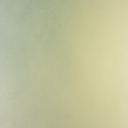
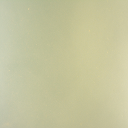
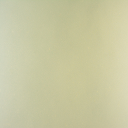
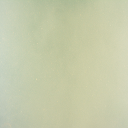
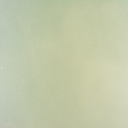
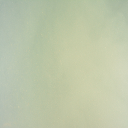
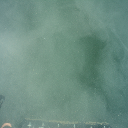
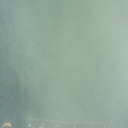
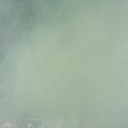
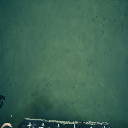
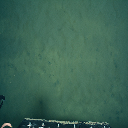
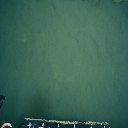

In [23]:
# see the outputs
pipeline.images

## Create a new pipeline with one more step

In [24]:
# Create a new pipeline with one more step
open_layer_params = {
    "convert": [
        {
            "mode": "bits",
            "params": {
                "output_bits": 8,
            },
        },
    ],
    "sampling": [{"mode": "percent", "params": {"value": 0.1}}],
}
pipeline_steps = [
    ("raw", OpenLayer, open_layer_params),
    ("gray", ColourLayer, {"mode": "grayscale"}),
]

In [25]:
# Instantiate the pipeline class and see the step described in the pipeline_steps variable
pipeline = Pipeline(
    config_file_path="../config_files/config_simple.yml",
    steps=pipeline_steps,
)
pipeline.steps

[('raw',
  paidiverpy.open_layer.open_layer.OpenLayer,
  {'convert': [{'mode': 'bits', 'params': {'output_bits': 8}}],
   'sampling': [{'mode': 'percent', 'params': {'value': 0.1}}],
   'name': 'raw',
   'step_name': 'raw'}),
 ('gray',
  paidiverpy.colour_layer.colour_layer.ColourLayer,
  {'mode': 'grayscale', 'name': 'gray', 'step_name': 'colour'})]

In [26]:
# See the pipeline
pipeline

In [27]:
# See the updated configuration file
pipeline.config

{
    "general": {
        "name": "raw",
        "step_name": "raw",
        "sample_data": "benthic_csv",
        "input_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/images",
        "output_path": "output",
        "metadata_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/metadata_benthic_csv.csv",
        "metadata_type": "CSV_FILE",
        "image_open_args": "PNG",
        "append_data_to_metadata": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/appended_metadata_benthic_csv.csv",
        "n_jobs": 1,
        "track_changes": true,
        "rename": "datetime",
        "sampling": [
            {
                "name": "sampling",
                "step_name": "sampling",
                "test": false,
                "params": {
                    "value": 0.1,
                    "raise_error": false
                },
                "mode": "percent"
            }
        ],
        "convert": [
            {
                "name": "convert",
                "step_name": "convert",
                "test": false,
                "params": {
                    "output_bits": 8,
                    "raise_error": false
                },
                "mode": "bits"
            }
        ]
    },
    "steps": [
        {
            "name": "gray",
            "step_name": "colour",
            "test": false,
            "params": {
                "method": "opencv",
                "invert_colours": false,
                "raise_error": false
            },
            "mode": "grayscale"
        }
    ]
}

In [28]:
# Run your pipeline
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2025-09-11 16:48:40 | Processing images using 1 cores


INFO:paidiverpy:Processing images using 1 cores


☁ paidiverpy ☁  |       INFO | 2025-09-11 16:48:40 | Running step 0: raw - OpenLayer


INFO:paidiverpy:Running step 0: raw - OpenLayer


☁ paidiverpy ☁  |       INFO | 2025-09-11 16:48:41 | Step 0 completed


INFO:paidiverpy:Step 0 completed


☁ paidiverpy ☁  |       INFO | 2025-09-11 16:48:41 | Running step 1: gray - ColourLayer


INFO:paidiverpy:Running step 1: gray - ColourLayer


☁ paidiverpy ☁  |       INFO | 2025-09-11 16:48:41 | Step 1 completed


INFO:paidiverpy:Step 1 completed



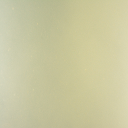
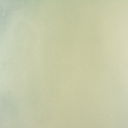
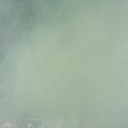
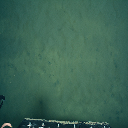
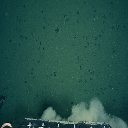
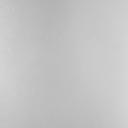
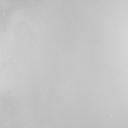
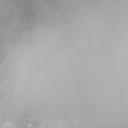
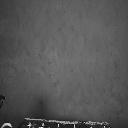
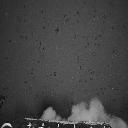

In [29]:
# See the ouput images
pipeline.images


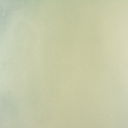
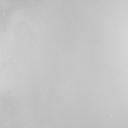

In [30]:
pipeline.images.show(image_number=1)

## Export pipeline to configuration file

After creating the pipeline, you can export it to a configuration file and reuse it

In [31]:
pipeline.export_config("new_config.yml")

In [32]:
pipeline = Pipeline(config_file_path="new_config.yml")

In [33]:
pipeline

In [17]:
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2025-09-11 13:31:51 | Processing images using 1 cores


INFO:paidiverpy:Processing images using 1 cores


☁ paidiverpy ☁  |       INFO | 2025-09-11 13:31:51 | Running step 0: raw - OpenLayer


INFO:paidiverpy:Running step 0: raw - OpenLayer


☁ paidiverpy ☁  |       INFO | 2025-09-11 13:31:52 | Step 0 completed


INFO:paidiverpy:Step 0 completed


☁ paidiverpy ☁  |       INFO | 2025-09-11 13:31:52 | Running step 1: gray - ColourLayer


INFO:paidiverpy:Running step 1: gray - ColourLayer


☁ paidiverpy ☁  |       INFO | 2025-09-11 13:31:52 | Step 1 completed


INFO:paidiverpy:Step 1 completed


In [18]:
pipeline.get_metadata()

,ID,XResolution,YResolution,ExposureTime,FNumber,ISO,image-datetime,MaxApertureValue,WhiteBalance,FocusPosition,...,temperature_c,positioning_ok,attitude_ok,depth_ok,altitude_ok,X,phototime,flag,point,filename
0,436,300,300,0.016667,8,200,2018-06-11 04:15:21,2.828427,FLASH,17,...,1.4697,1,1,1,1,NaN,2018-06-11 04:15:21,0,POINT (-153.6053176 11.25169125),2018-06-11T04:15:21
1,454,300,300,0.016667,8,200,2018-06-11 04:18:21,2.828427,FLASH,17,...,1.4557,1,1,1,1,NaN,2018-06-11 04:18:21,0,POINT (-153.60529078 11.251633),2018-06-11T04:18:21
2,455,300,300,0.016667,8,200,2018-06-11 04:18:31,2.828427,FLASH,17,...,1.4606,1,1,1,1,NaN,2018-06-11 04:18:31,0,POINT (-153.60528577 11.25163374),2018-06-11T04:18:31
3,474,300,300,0.016667,8,200,2018-06-11 04:21:41,2.828427,FLASH,17,...,1.4385,1,1,1,1,NaN,2018-06-11 04:21:41,0,POINT (-153.60513384 11.25165041),2018-06-11T04:21:41
4,477,300,300,0.016667,8,200,2018-06-11 04:22:11,2.828427,FLASH,17,...,1.4326,1,1,1,1,NaN,2018-06-11 04:22:11,0,POINT (-153.60511554 11.25165272),2018-06-11T04:22:11
